# Part 2 / 4 -- Build & train Dual-CNN + baselines
### Kaggle setup for this notebook
- Add Input: `uraninjo/augmented-alzheimer-mri-dataset` (needed to read the actual images)
- Add Input: **Part 1's notebook output** (Add Input -> Notebook Output Files -> Part 1 notebook)
  -> gives you `train_df.csv`, `val_df.csv`, `test_df.csv`, `label_classes.json`
- Accelerator: **GPU T4** (this is the heavy training part)
- Internet: on (first run downloads ImageNet weights)

### What this notebook does
Rebuilds the input pipeline from Part 1's split, builds the Dual-CNN
(InceptionResNetV2 + ResNet50 fusion) and the two single-backbone baselines,
trains all three, and saves the trained models + training curves.

### Before running
Edit `PART1_INPUT_DIR` below to match the path Kaggle mounts Part 1's output at
(shown in the right-hand Data panel once you add it as input).

### At the end
Save Version -> Save & Run All (Commit), then add this notebook's output as an
input source in Part 3.


In [1]:
import os, random, json, pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras import layers, Model

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

# tk.keras.mixed_precision.set_global_policy('mixed_float16')  # optional, matches earlier drafts

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
from pathlib import Path  # defensive re-import, in case cells are run out of order

# Confirmed real mount path for this Kaggle account/notebook setup.
# If you re-attach Part 1's output under a different notebook title later,
# check the exact folder name with: import os; os.listdir("/kaggle/input/notebooks/jannatulakiba70023")
PART1_INPUT_DIR = Path("/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir")

# Diagnostic: list what is actually mounted, so a wrong/renamed path fails loudly
import os
print("Files under PART1_INPUT_DIR:")
for root, dirs, files in os.walk(PART1_INPUT_DIR):
    for f in files:
        print(os.path.join(root, f))

train_df = pd.read_csv(PART1_INPUT_DIR / "train_df.csv")
val_df   = pd.read_csv(PART1_INPUT_DIR / "val_df.csv")
test_df  = pd.read_csv(PART1_INPUT_DIR / "test_df.csv")
with open(PART1_INPUT_DIR / "label_classes.json") as f:
    classes_ = json.load(f)

NUM_CLASSES = len(classes_)
print("Classes:", classes_)
print("Rows:", len(train_df), len(val_df), len(test_df))

Files under PART1_INPUT_DIR:
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/val_df.csv
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/label_classes.json
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/__results__.html
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/class_distribution.pdf
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/__notebook__.ipynb
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/train_df.csv
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/__output__.json
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/test_df.csv
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/class_distribution.png
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/custom.css
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/__results___files/__results___9_0.png
/kaggle/input/notebooks/jannatulakiba70023/part1-input-dir/__results___files/__results___11_0.png
/kaggle/input/notebook

In [3]:
# 5. Image pipeline
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="train_augmentation")

def decode_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_ds(part, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (part["filepath"].values, part["y"].values)
    )
    if training:
        ds = ds.shuffle(len(part), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x,y: (augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, True)
val_ds   = make_ds(val_df, False)
test_ds  = make_ds(test_df, False)


train_ds = make_ds(train_df, True)
val_ds   = make_ds(val_df, False)
test_ds  = make_ds(test_df, False)

I0000 00:00:1788034201.620640     384 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788034201.622794     384 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# 6. Build Dual-CNN
from tensorflow.keras import layers, Model

inp = layers.Input(shape=(*IMG_SIZE, 3), name="image")

# ImageNet preprocessing inside each branch
x1 = tf.keras.applications.inception_resnet_v2.preprocess_input(inp * 255.0)
x2 = tf.keras.applications.resnet50.preprocess_input(inp * 255.0)

base1 = tf.keras.applications.InceptionResNetV2(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE,3)
)
base2 = tf.keras.applications.ResNet50(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE,3)
)
base1.trainable = False
base2.trainable = False

b1 = base1(x1, training=False)
b1 = layers.GlobalAveragePooling2D(name="inception_gap")(b1)
# FIX: InceptionResNetV2 and ResNet50 GAP outputs live on very different
# feature scales. Concatenating them raw let one branch dominate the shared
# Dense layer's gradients, which is why the fused model previously stalled
# around 60% val accuracy while either backbone alone reached ~98%.
# BatchNorm puts both branches on a comparable scale before fusion.
b1 = layers.BatchNormalization(name="inception_gap_bn")(b1)
b1 = layers.Dropout(0.30)(b1)

b2 = base2(x2, training=False)
b2 = layers.GlobalAveragePooling2D(name="resnet_gap")(b2)
b2 = layers.BatchNormalization(name="resnet_gap_bn")(b2)
b2 = layers.Dropout(0.30)(b2)

fused = layers.Concatenate(name="dual_cnn_fused_features")([b1, b2])
embedding = layers.Dense(512, activation="relu", name="fusion_embedding")(fused)
embedding = layers.Dropout(0.40)(embedding)
out = layers.Dense(
    NUM_CLASSES, activation="softmax", name="classifier", dtype="float32"
)(embedding)  # FIX: force float32 output under the global mixed_float16 policy

dual_cnn = Model(inp, out, name="DualCNN_InceptionResNetV2_ResNet50")
dual_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dual_cnn.summary()


Model: "DualCNN_InceptionResNetV2_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Multiply)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ image[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ multiply[0][0]    │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_resnet_v2 │ (None, 5, 5,      │ 54,336,736 │ subtract[0][0]    │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_gap       │ (None, 1536)      │          0 │ inception_resnet… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_gap          │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_gap_bn    │ (None, 1536)      │      6,144 │ inception_gap[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_gap_bn       │ (None, 2048)      │      8,192 │ resnet_gap[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1536)      │          0 │ inception_gap_bn

 Total params: 79,776,356 (304.32 MB)

 Trainable params: 1,844,740 (7.04 MB)

 Non-trainable params: 77,931,616 (297.29 MB)

In [5]:
# 7. Generic single-CNN builder
def build_single_cnn(name, backbone_cls, preprocess_fn):
    inp = layers.Input(shape=(*IMG_SIZE,3))
    # FIX: `inp` comes from decode_resize() as a [0,1]-scaled float image, but
    # every ImageNet-pretrained backbone expects its own specific preprocessing
    # (e.g. ResNet50 wants Caffe-style BGR + mean subtraction, InceptionResNetV2
    # wants [-1,1] scaling). The Dual-CNN branch above already does this
    # correctly per-backbone; this baseline builder previously skipped it
    # entirely, which would make these baselines perform worse for reasons
    # unrelated to architecture -- not a fair ablation comparison.
    x_pre = preprocess_fn(inp * 255.0)
    x = backbone_cls(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE,3))(x_pre, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    emb = layers.Dense(512, activation="relu", name="embedding")(x)
    x = layers.Dropout(0.40)(emb)
    out = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)  # FIX: float32 under mixed precision
    model = Model(inp, out, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Optional: run these baselines before the proposed model.
baseline_inception = build_single_cnn(
    "Baseline_InceptionResNetV2",
    tf.keras.applications.InceptionResNetV2,
    tf.keras.applications.inception_resnet_v2.preprocess_input,
)

In [6]:
baseline_resnet = build_single_cnn(
    "Baseline_ResNet50",
    tf.keras.applications.ResNet50,
    tf.keras.applications.resnet50.preprocess_input,
)

In [7]:
# 8. Train callbacks
ckpt_dir = Path("./checkpoints")
ckpt_dir.mkdir(exist_ok=True)

def callbacks_for(name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=7, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7
        ),
        tf.keras.callbacks.ModelCheckpoint(
            str(ckpt_dir / f"{name}.keras"),
            monitor="val_loss", save_best_only=True
        )
    ]

# Train baselines if desired -- pass the same class_weight computed in the
# Dual-CNN training cell below for a fair, apples-to-apples comparison:
# baseline_inception.fit(train_ds, validation_data=val_ds, epochs=30,
#                         class_weight=class_weight_dual_cnn,
#                         callbacks=callbacks_for("baseline_inception"))
# baseline_resnet.fit(train_ds, validation_data=val_ds, epochs=30,
#                      class_weight=class_weight_dual_cnn,
#                      callbacks=callbacks_for("baseline_resnet"))

In [8]:
# Train baseline models with the same class-weighting scheme used for Dual-CNN
train_class_counts = train_df["y"].value_counts().sort_index().to_numpy()
sqrt_class_weights = np.sqrt(train_class_counts.max() / train_class_counts)
class_weight_dual_cnn = dict(enumerate(sqrt_class_weights))
print("Sqrt-balanced class weights:", class_weight_dual_cnn)

history_baseline_inception = baseline_inception.fit(
    train_ds, validation_data=val_ds, epochs=30,
    class_weight=class_weight_dual_cnn,
    callbacks=callbacks_for("baseline_inception")

)

Sqrt-balanced class weights: {0: np.float64(1.870145618322497), 1: np.float64(7.076239872397438), 2: np.float64(1.0), 3: np.float64(1.1781765859213347)}
Epoch 1/30


2026-08-29 20:12:04.655348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 20:12:04.800557: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 20:12:05.135879: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 20:12:05.275576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788034360.099070     446 device_compiler.h:196]

260/260 ━━━━━━━━━━━━━━━━━━━━ 246s 387ms/step - accuracy: 0.5589 - loss: 1.2531 - val_accuracy: 0.6427 - val_loss: 0.7985 - learning_rate: 1.0000e-04
Epoch 2/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 92s 352ms/step - accuracy: 0.6861 - loss: 0.9083 - val_accuracy: 0.6979 - val_loss: 0.7314 - learning_rate: 1.0000e-04
Epoch 3/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 92s 353ms/step - accuracy: 0.7868 - loss: 0.6340 - val_accuracy: 0.7437 - val_loss: 0.7164 - learning_rate: 1.0000e-04
Epoch 4/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 93s 357ms/step - accuracy: 0.8562 - loss: 0.4583 - val_accuracy: 0.7896 - val_loss: 0.5341 - learning_rate: 1.0000e-04
Epoch 5/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 94s 362ms/step - accuracy: 0.8882 - loss: 0.3710 - val_accuracy: 0.8344 - val_loss: 0.5203 - learning_rate: 1.0000e-04
Epoch 6/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 89s 340ms/step - accuracy: 0.9103 - loss: 0.3072 - val_accuracy: 0.8250 - val_loss: 0.5282 - learning_rate: 1.0000e-04
Epoch 7/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 89s 341ms/step -

In [9]:
history_baseline_resnet = baseline_resnet.fit(
    train_ds, validation_data=val_ds, epochs=30,
    class_weight=class_weight_dual_cnn,
    callbacks=callbacks_for("baseline_resnet")
)

Epoch 1/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 122s 237ms/step - accuracy: 0.5510 - loss: 1.2759 - val_accuracy: 0.5906 - val_loss: 1.2899 - learning_rate: 1.0000e-04
Epoch 2/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 59s 225ms/step - accuracy: 0.6560 - loss: 0.9848 - val_accuracy: 0.6729 - val_loss: 0.7048 - learning_rate: 1.0000e-04
Epoch 3/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 57s 218ms/step - accuracy: 0.7260 - loss: 0.7686 - val_accuracy: 0.5260 - val_loss: 1.5521 - learning_rate: 1.0000e-04
Epoch 4/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 59s 227ms/step - accuracy: 0.7827 - loss: 0.6548 - val_accuracy: 0.7583 - val_loss: 0.5670 - learning_rate: 1.0000e-04
Epoch 5/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 57s 219ms/step - accuracy: 0.8252 - loss: 0.5307 - val_accuracy: 0.6917 - val_loss: 0.8730 - learning_rate: 1.0000e-04
Epoch 6/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 57s 218ms/step - accuracy: 0.8399 - loss: 0.4774 - val_accuracy: 0.6292 - val_loss: 1.2305 - learning_rate: 1.0000e-04
Epoch 7/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 57s 2

In [10]:
# 9. Train Dual-CNN
# FIX: this class-imbalance issue was already identified and handled in the
# first pipeline (sqrt-balanced class weights) but was dropped here -- the
# same imbalance (e.g. ModerateDemented being rare) applies to this dataset
# regardless of which model architecture is used.
train_class_counts = train_df["y"].value_counts().sort_index().to_numpy()
sqrt_class_weights = np.sqrt(train_class_counts.max() / train_class_counts)
class_weight_dual_cnn = dict(enumerate(sqrt_class_weights))
print("Sqrt-balanced class weights:", class_weight_dual_cnn)

history = dual_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dual_cnn,
    callbacks=callbacks_for("dual_cnn")
)


Sqrt-balanced class weights: {0: np.float64(1.870145618322497), 1: np.float64(7.076239872397438), 2: np.float64(1.0), 3: np.float64(1.1781765859213347)}
Epoch 1/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 106s 261ms/step - accuracy: 0.4430 - loss: 2.0432 - val_accuracy: 0.5958 - val_loss: 0.8856 - learning_rate: 1.0000e-04
Epoch 2/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 53s 202ms/step - accuracy: 0.5401 - loss: 1.5770 - val_accuracy: 0.6333 - val_loss: 0.8261 - learning_rate: 1.0000e-04
Epoch 3/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 49s 190ms/step - accuracy: 0.5822 - loss: 1.3997 - val_accuracy: 0.6521 - val_loss: 0.8298 - learning_rate: 1.0000e-04
Epoch 4/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 54s 205ms/step - accuracy: 0.6012 - loss: 1.3168 - val_accuracy: 0.6729 - val_loss: 0.7776 - learning_rate: 1.0000e-04
Epoch 5/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 54s 205ms/step - accuracy: 0.6171 - loss: 1.2452 - val_accuracy: 0.6740 - val_loss: 0.7642 - learning_rate: 1.0000e-04
Epoch 6/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 50s 190ms/s

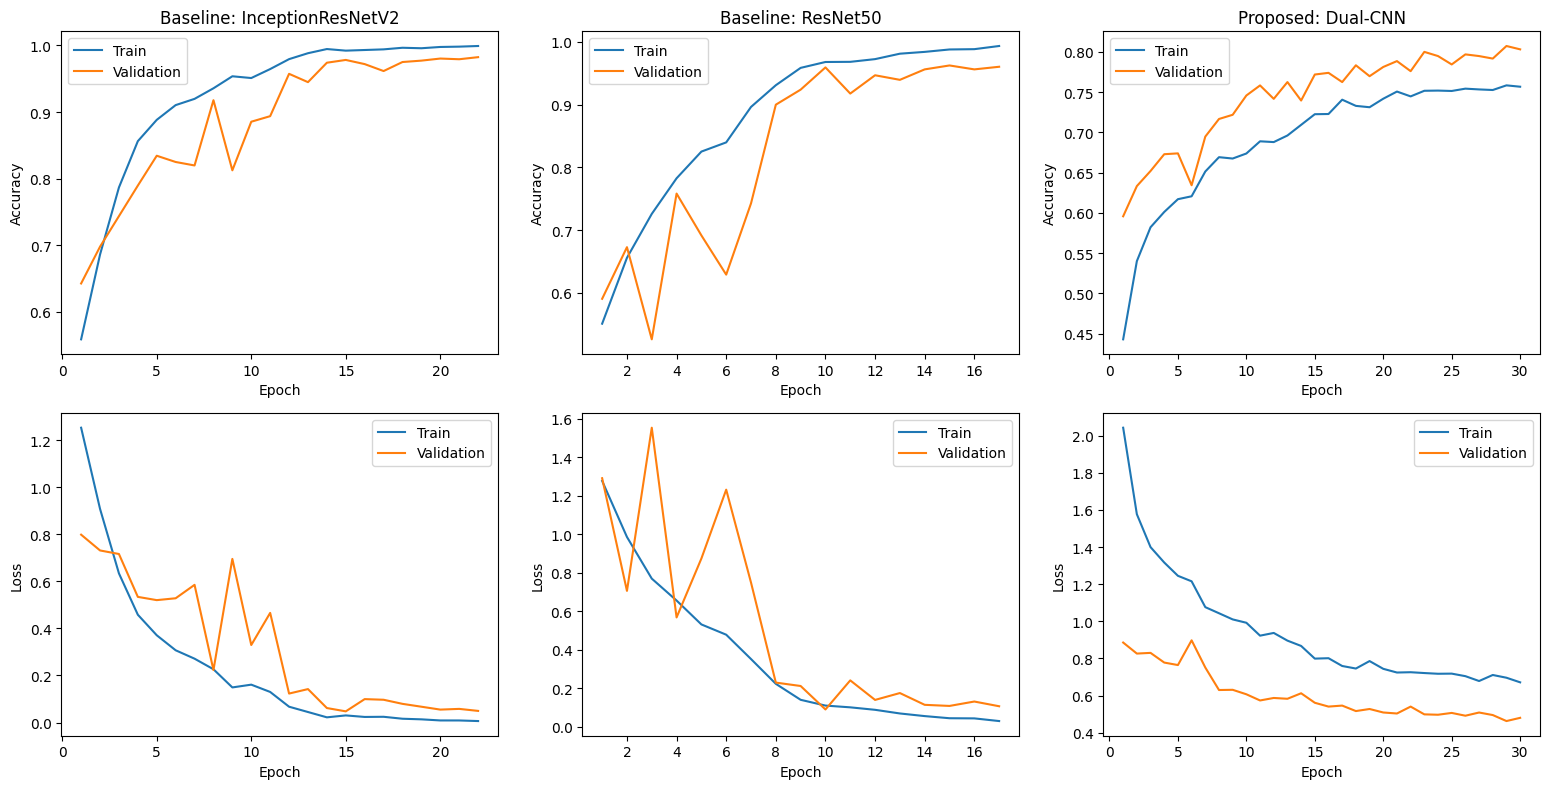

Saved: figures/Fig4_Training_Validation_Accuracy_Loss.png


In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
FIG_DIR = Path("./figures")
FIG_DIR.mkdir(exist_ok=True)
# Figure 4 -- training/validation accuracy & loss curves
models_for_fig4 = [
    ("Baseline: InceptionResNetV2", history_baseline_inception.history),
    ("Baseline: ResNet50", history_baseline_resnet.history),
    ("Proposed: Dual-CNN", history.history),
]

fig, axes = plt.subplots(2, len(models_for_fig4), figsize=(5.2 * len(models_for_fig4), 8))

for col, (title, h) in enumerate(models_for_fig4):
    ep = range(1, len(h["accuracy"]) + 1)
    axes[0, col].plot(ep, h["accuracy"], label="Train")
    axes[0, col].plot(ep, h["val_accuracy"], label="Validation")
    axes[0, col].set_title(title)
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].set_ylabel("Accuracy")
    axes[0, col].legend()

    axes[1, col].plot(ep, h["loss"], label="Train")
    axes[1, col].plot(ep, h["val_loss"], label="Validation")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylabel("Loss")
    axes[1, col].legend()

plt.tight_layout()
fig4_path = FIG_DIR / "Fig4_Training_Validation_Accuracy_Loss.png"
plt.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig4_path}")

## Save checkpoint for Part 3
Saves the three trained models and their training histories.

In [12]:
# Save checkpoint artifacts for Part 3
dual_cnn.save("/kaggle/working/dual_cnn.keras")
baseline_inception.save("/kaggle/working/baseline_inception.keras")
baseline_resnet.save("/kaggle/working/baseline_resnet.keras")

with open("/kaggle/working/histories.pkl", "wb") as f:
    pickle.dump({
        "dual_cnn": history.history,
        "baseline_inception": history_baseline_inception.history,
        "baseline_resnet": history_baseline_resnet.history,
    }, f)

print("Saved: dual_cnn.keras, baseline_inception.keras, baseline_resnet.keras, histories.pkl")
print("Now: Save Version -> Save & Run All (Commit), then use this notebook's")
print("output as an input source in Part 3.")


Saved: dual_cnn.keras, baseline_inception.keras, baseline_resnet.keras, histories.pkl
Now: Save Version -> Save & Run All (Commit), then use this notebook's
output as an input source in Part 3.
